# Классификатор таблеток

**Бизнес-контекст**<br>
На небольших фармацевтических предприятиях таблетки обычно фасуются по банкам вручную. Последние годы вводятся маленькие автоматические линии для фасовки — они механически расфасовывают таблетки из большой ёмкости по маленьким. 

**Проблема**<br>
Процесс фасовки автоматизирован не полностью, специалист должен перепроверять каждую упаковку таблеток. Если в партию случайно попадёт не та таблетка, это может нанести вред здоровью пациента.

**Бизнес-задача**<br>
Добавить автоматический контроль качества через компьютерное зрение. Для этого нужно разработать алгоритм распознавания таблеток по фото. Это прототип, поэтому достаточно достичь качества распознавания в 75%.

**Формальная задача**<br>
Решить задачу классификации, используя CNN. Входные данные — фото таблетки, требуемый результат — название таблетки (из заданного списка).


**Содержание:**

0. [Подготовка](#step_0)
1. [Загрузка и предобработка данных](#step_1)
2. [Объявление моделей](#step_2)
    1. [Собственная модель](#step_2_1)
    2. [EfficientNet](#step_2_2)
    3. [MobileNet](#step_2_3)
3. [Обучение и дообучение](#step_3)
    1. [Собственная модель](#step_3_1)
    2. [EfficientNet](#step_3_2)
    3. [MobileNet](#step_3_3)
5. [Оценка качества](#step_4)
    1. [Собственная модель](#step_4_1)
    2. [EfficientNet](#step_4_2)
    3. [MobileNet](#step_4_3)
7. [Выводы](#step_5)

<a id='step_0'></a>
## 0. Подготовка

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import random

from PIL import Image
from tqdm import tqdm

from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor, Normalize, Resize
from torchvision.transforms.v2 import RandomRotation, RandomPhotometricDistort, RandomHorizontalFlip, RandomVerticalFlip, Compose

from torch.utils.data import Dataset, DataLoader, random_split

import torch
import torch.nn as nn
import torch.optim as optim

from torchinfo import summary

from torchvision.models import mobilenet_v3_small, efficientnet_b0

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Определяем доступное устойство для работы с моделью.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
RAND_SEED = 42

In [4]:
random.seed(RAND_SEED)
np.random.seed(RAND_SEED)

In [5]:
# для запуска ноутбука на Kaggle
IS_KAGGLE = True

Определяем пути до данных.

In [6]:
if IS_KAGGLE:
    DATASET_PATH = '/kaggle/input/datasets/ruslanmushtakov/meds-dataset'
    OUTPUT_PATH = '/kaggle/working/'
else:
    DATASET_PATH = './data/dataset/'
    OUTPUT_PATH = '.'

<a id='step_1'></a>
## 1. Загрузка и предобработка данных

**Задание:**
1. Загрузите датасеты для обучения и тестирования, для каждого определите этапы предобработки. Полученные датасеты, упакованные для использования в обучении, поместите в переменные train_loader и val_loader.
2. Выведите количество классов, количество изображений в обоих датасетах.

Загрузим датасеты. У нас уже явно определены отдельные датасеты для обучения и тестирования - воспользуемся этим. Сразу обработывать не будем, сначала посмотрим на сырые изображения. Позже трансформируем отдельно.

In [7]:
train_dataset_path = f'{DATASET_PATH}/ogyeiv2/train'
raw_train_dataset = ImageFolder(train_dataset_path)

val_dataset_path = f'{DATASET_PATH}/ogyeiv2/test'
raw_val_dataset = ImageFolder(val_dataset_path)

Таким образом у нас датасета train и val. Посмотрим на их характеристики до всех преобразований.

In [8]:
print(f'Количество изображений в train: {len(raw_train_dataset)} (количество классов: {len(raw_train_dataset.classes)})')
print(f'Количество изображений в val: {len(raw_val_dataset)} (количество классов: {len(raw_val_dataset.classes)})')

Количество изображений в train: 2352 (количество классов: 84)
Количество изображений в val: 504 (количество классов: 84)


Отдельно сохраним названия классов и их количество.

In [9]:
classes_names = raw_train_dataset.classes
num_classes = len(classes_names)

Подготовим функцию показа изображения из датасет по указанному классу.

In [10]:
def show_images_from_class(dataset, class_name, n=5):
    base_dataset = dataset.dataset if hasattr(dataset, 'dataset') else dataset
    classes = base_dataset.classes
    
    class_idx = classes.index(class_name)

    indices = []

    for i in range(len(dataset)):
        _, label = dataset[i]
        if label == class_idx:
            indices.append(i)

    sample_indices = random.sample(indices, min(n, len(indices)))

    plt.figure(figsize=(3*n,3))

    for i, idx in enumerate(sample_indices):
        img, label = dataset[idx]

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(classes[label])
        plt.axis("off")

    plt.show()

Посмотрим на изображения из тренировочного датасета. Пока мы специально не перемешиывали картинки в датасете, поэтому будем выбирать картинки случайно.

In [11]:
def show_rand_images(dataset):
    fig, axes = plt.subplots(2, 5, figsize=(16, 8))
    axes = axes.ravel()

    for i in range(10):
        idx = random.randint(0, len(dataset)-1)
        image, label = dataset[idx]
        if hasattr(dataset, 'classes'):
            class_name = dataset.classes[label]
        else:
            class_name = dataset.dataset.classes[label]
        axes[i].imshow(image)
        axes[i].set_title(class_name, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()

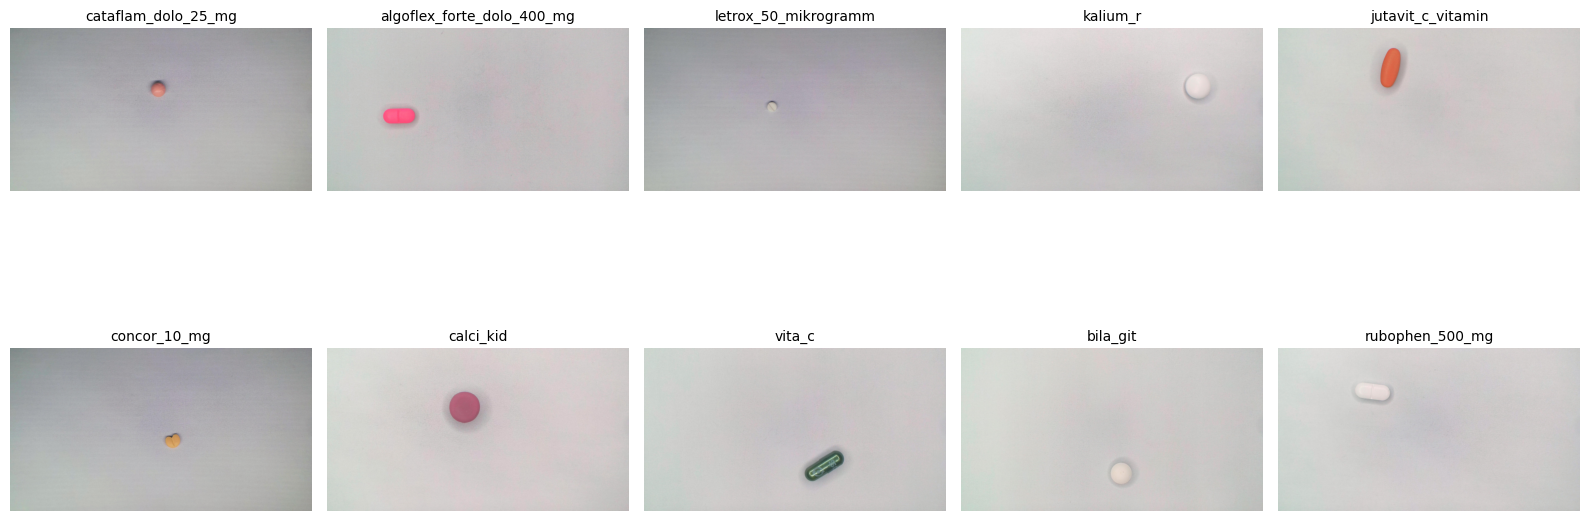

In [12]:
show_rand_images(raw_train_dataset)

Видно, что изображения цветные, все таблетки располагаются на светлом однородном фоне. При этом на фотографиях используются различные настройки освещения. Глобально таблетки уже расположены в разных частях картинки и под разным углом, т.е. аугментация в данном направлении не особо то и нужна. Что действительно было бы полезно, так это попробовать разнообразить контрастность и тон изображений, т.к. в реальной жизни могут быть менее качественные фотографии.<br>
__NOTE:__ при обучении аугментация с помощью изменения контрастности и тона, занимает слишком много времени. Было решено __отколючить__ ее в данном проекте. Тем более, это не необходимая операция - текущий датасет уже учитывает этот момент (разные источники света).

Подготовим операции для трансформации датасетов. Помимо аугментации для обучающей выборки, все изображения приведем к нужному размеру, преобразуем в тензор и нормализуем.<br>
Дополнительно, создадим трансформацию только над картинками, чтобы визуализировать, какие именно изображения пойдут на обучение.

In [13]:
train_transforms = Compose([
    # RandomPhotometricDistort(p=0.2, contrast=[0.8, 1.2], hue=[-0.1, 0.1]),
    Resize((224, 224)),
    ToTensor(),
    Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

val_transforms = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

check_train_transforms = Compose([
    RandomPhotometricDistort(p=0.2, contrast=[0.8, 1.2], hue=[-0.1, 0.1]),
    Resize((224, 224))
])

Подготовим класс-обёртка для трансформации.

In [14]:
class TransformDataset(Dataset):
  def __init__(self, dataset, transforms):
    super().__init__()
    self.dataset = dataset
    self.transforms = transforms

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    x, y = self.dataset[idx]
    return self.transforms(x), y

Добавим трансформации к датасетам

In [15]:
check_train_dataset = TransformDataset(raw_train_dataset, check_train_transforms)

train_dataset = TransformDataset(raw_train_dataset, train_transforms)
val_dataset = TransformDataset(raw_val_dataset, val_transforms)

Посмотрим, как выглядят изображения для обучения (до преобразования в тензор и нормализации).

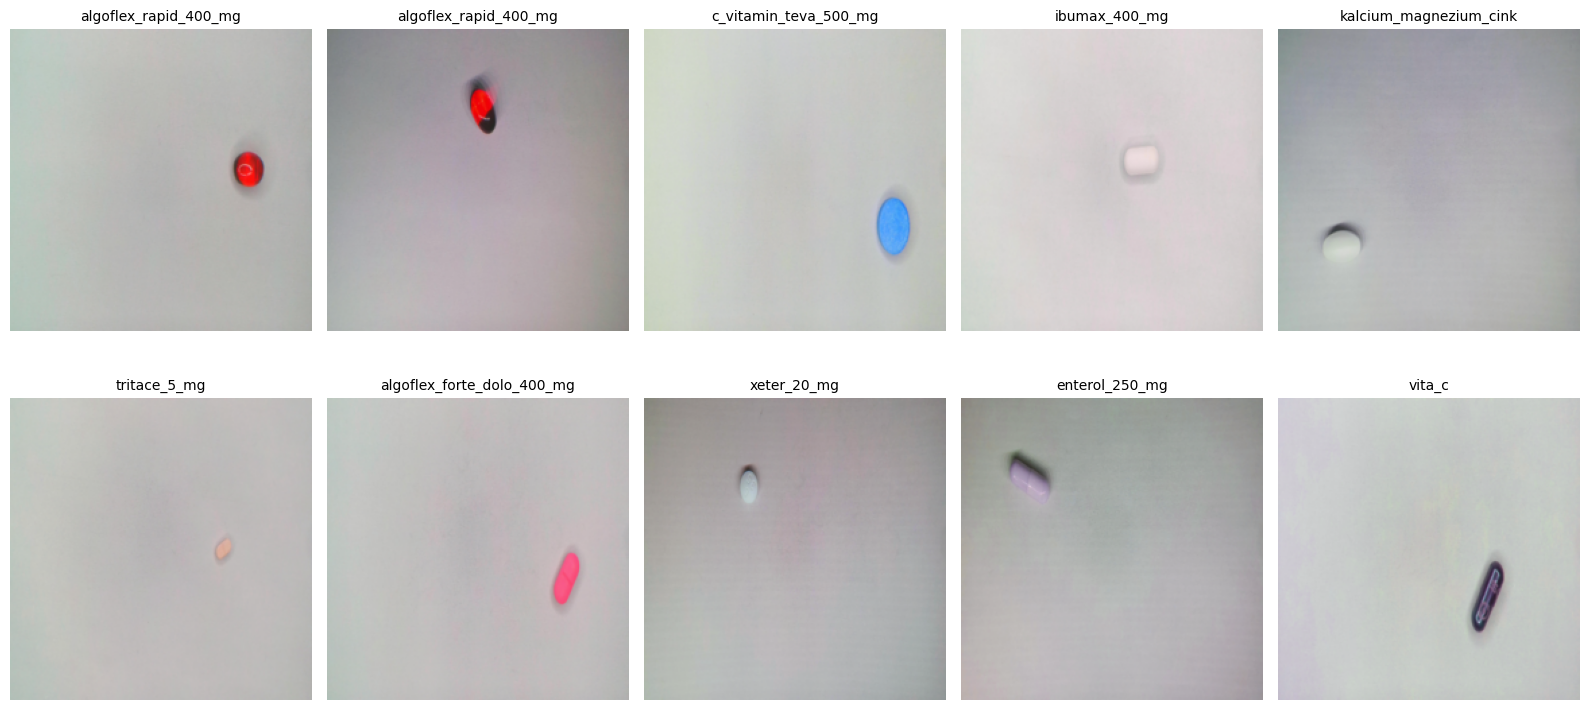

In [16]:
show_rand_images(check_train_dataset)

Упакуем датасеты в DataLoader

In [17]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

In [18]:
print(f'Количество изображений в train: {len(train_dataset)} (количество классов: {len(train_dataset.dataset.classes)})')
print(f'Количество изображений в val: {len(val_dataset)} (количество классов: {len(val_dataset.dataset.classes)})')

Количество изображений в train: 2352 (количество классов: 84)
Количество изображений в val: 504 (количество классов: 84)


**Выводы по этапу**

1. Необходимые DataLoader подготовлены.
2. Количество изображений на train и val соотносятся в первоначальной пропорции. Количество классов совпадает.

<a id='step_2'></a>
## 2. Объявление модели

**Задание:**
1. Создайте классификатор изображений, подходящий для классификации таблеток. Если часть весов нужно заморозить, сделайте это.

Проведем эксперимент - попробуем подготовить несколько моделей. Одну обучим с нуля, 2 возьмем предобученные. В качестве предобученных возьмем EfficientNet и MobileNet, первая - точная, но медленная, вторая - маленькая и быстрая, но чуть с меньшей точностью. По итогу обучим/дообучим все три модели и сравним результаты.

<a id='step_2_1'></a>
### 2.1. Собственная модель

Подготовим собственную модель. Изображения у нас сравнительно простые - разные виды таблеток, ничего дополнительного на изображениях нет. Пусть в нашей модели будет 2 свёрточных блока. После каждой свёртки добавим батч-норм, ReLU и макс-пулинг с окном 2х2. После выделения признаков нужно перейти к класификации -> добавим глобальный пулинг и полносвязный слой на необходимое количество класов.

In [19]:
class MedsClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()

        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(2, 2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        
        self.conv1 = nn.Conv2d(3, 32, 3, padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, 3, padding='same')
        self.bn2 = nn.BatchNorm2d(64)

        self.flatten = nn.Flatten()
        self.classifier = nn.Linear(64, n_classes)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.maxpool(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.maxpool(out)

        out = self.avgpool(out)
        out = self.flatten(out)
        out = self.classifier(out)

        return out

In [20]:
custom_model = MedsClassifier(num_classes)

Явно укажем, что нужно обучить все слои сети.

In [21]:
for param in custom_model.parameters():
    param.requires_grad = True

In [22]:
summary(custom_model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
MedsClassifier                           [1, 84]                   --
├─Conv2d: 1-1                            [1, 32, 224, 224]         896
├─BatchNorm2d: 1-2                       [1, 32, 224, 224]         64
├─ReLU: 1-3                              [1, 32, 224, 224]         --
├─MaxPool2d: 1-4                         [1, 32, 112, 112]         --
├─Conv2d: 1-5                            [1, 64, 112, 112]         18,496
├─BatchNorm2d: 1-6                       [1, 64, 112, 112]         128
├─ReLU: 1-7                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-8                         [1, 64, 56, 56]           --
├─AdaptiveAvgPool2d: 1-9                 [1, 64, 1, 1]             --
├─Flatten: 1-10                          [1, 64]                   --
├─Linear: 1-11                           [1, 84]                   5,460
Total params: 25,044
Trainable params: 25,044
Non-trainable params: 0
Total 

<a id='step_2_2'></a>
### 2.2. EfficientNet

Выгрузим готовую модель с уже предобученными весами.

In [23]:
efficientnet_model = efficientnet_b0(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 176MB/s]


Посмотрим на верхнеуровневые слои.

In [24]:
for name, module in efficientnet_model.named_children():
    print(name)

features
avgpool
classifier


Посмотрим на структуру классификатора

In [25]:
print(efficientnet_model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


Модель обучалась классифицировать изображения на ImageNet. У нас классов меньше, следоавтельно нужно подтюнить модель.

In [26]:
efficientnet_model.classifier = nn.Linear(1280, num_classes)

Для обучения, мы не хотим трогать часть с извлечением признаков Feature Extractor, а дообучиь только классификатор.

In [27]:
# Заморозка всей модели
for param in efficientnet_model.parameters():
    param.requires_grad = False

# Разморозка классификатора
for param in efficientnet_model.classifier.parameters():
    param.requires_grad = True

Посмотрим на новую конфигурацию модели.

In [28]:
summary(efficientnet_model, input_size=(1, 3, 224, 224), depth=1)

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 84]                   --
├─Sequential: 1-1                                       [1, 1280, 7, 7]           (4,007,548)
├─AdaptiveAvgPool2d: 1-2                                [1, 1280, 1, 1]           --
├─Linear: 1-3                                           [1, 84]                   107,604
Total params: 4,115,152
Trainable params: 107,604
Non-trainable params: 4,007,548
Total mult-adds (Units.MEGABYTES): 384.69
Input size (MB): 0.60
Forward/backward pass size (MB): 107.88
Params size (MB): 16.46
Estimated Total Size (MB): 124.94

<a id='step_2_3'></a>
### 2.3. MobileNet

Выполним те же самые действия, что и для EfficientNet.

In [29]:
mobilenet_model = mobilenet_v3_small(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 152MB/s]


In [30]:
for name, module in mobilenet_model.named_children():
    print(name)

features
avgpool
classifier


In [31]:
print(mobilenet_model.classifier)

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=1000, bias=True)
)


In [32]:
mobilenet_model.classifier = nn.Linear(576, num_classes)

In [33]:
# Заморозка всей модели
for param in mobilenet_model.parameters():
    param.requires_grad = False

# Разморозка классификатора
for param in mobilenet_model.classifier.parameters():
    param.requires_grad = True

In [34]:
summary(mobilenet_model, input_size=(1, 3, 224, 224), depth=1)

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 84]                   --
├─Sequential: 1-1                                  [1, 576, 7, 7]            (927,008)
├─AdaptiveAvgPool2d: 1-2                           [1, 576, 1, 1]            --
├─Linear: 1-3                                      [1, 84]                   48,468
Total params: 975,476
Trainable params: 48,468
Non-trainable params: 927,008
Total mult-adds (Units.MEGABYTES): 54.96
Input size (MB): 0.60
Forward/backward pass size (MB): 22.63
Params size (MB): 3.90
Estimated Total Size (MB): 27.13

**Выводы по этапу**

Создано 3 классификатора изображений, готовые к обучению.
* `custom_model`: 25,044 параметров для обучения
* `efficientnet_model`: 107,604 параметров для обучения 
* `mobilenet_model`: 48,468 параметров для обучения

<a id='step_3'></a>
## 3. Обучение и дообучение

**Задание:**
1. Обучите или дообучите классификатор на датасете таблеток. Сохраните обученную модель.

In [35]:
def move_batch_to_device(batch, device):
    '''
    Перенос batch на device
    '''
    images = batch[0].to(device, non_blocking=True)
    labels = batch[1].to(device, non_blocking=True)
    return images, labels

In [36]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch_idx, verbose=False):
    '''
    Обучение на одной эпохе
    '''
    model.train()
    
    total_loss = 0.
    running_loss = 0.0
    last_loss = 0.0

    # будем логировать лосс на обучении 3 раза за эпоху
    verbose_idx = int(len(loader) / 3)

    for batch_idx, batch in enumerate(loader):
        # Извлечение батча
        images, labels = move_batch_to_device(batch, device)
        # Обнуление градиентов
        optimizer.zero_grad()
        # Прямое распространение
        outputs = model(images)
        # Подсчёт ошибки
        loss = criterion(outputs, labels)
        # Обратное распространение
        loss.backward()
        # Обновление весов
        optimizer.step()

        total_loss += loss.item()

        if verbose:
            # следим за ошибкой во время эпохи
            running_loss += loss.item()
            if batch_idx and batch_idx % verbose_idx == 0:
                last_loss = running_loss / verbose_idx # средняя ошибка за verbose_idx батчей
                print(f'epoch: {epoch_idx}, batch: {batch_idx}, avg_loss in last {verbose_idx} batches: {last_loss:.4f}')
                running_loss = 0.0

    return total_loss / len(loader)

In [37]:
@torch.no_grad()
def evaluate_quality(model, loader, device, classes_names):
    '''
    Оценка качества модели на валидации
    '''
    model.eval()
    
    # Расчёт предсказанных и истинных меток для всех примеров в loader
    labels_predicted = []
    labels_true = []
    
    for batch in loader:
        images, labels = move_batch_to_device(batch, device)

        outputs = model(images)
        # выбираем класс с максимальным логитом для каждого объекта в батче
        # torch.max возвращает (значения максимумов, индексы максимумов)
        _, predicted = torch.max(outputs, 1) # argmax по всем объектам в батче
        labels_predicted.extend(predicted.cpu().numpy())
        labels_true.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(labels_true, labels_predicted)
    report = classification_report(labels_true, labels_predicted, target_names=classes_names, output_dict=True, zero_division=0)
    cm = confusion_matrix(labels_true, labels_predicted, labels=range(len(classes_names)))

    return accuracy, report, cm

In [38]:
@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    '''
    Замер лосса на валидации
    '''
    model.eval()
    
    total_loss = 0.0
    labels_predicted = []
    labels_true = []

    for batch in loader:
        images, labels = move_batch_to_device(batch, device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item()

    return total_loss / len(loader)

In [39]:
def train_model(model, model_path, train_loader, val_loader, classes_names, num_epochs=5, device='cpu', verbose=False):
    '''
    Обучение модели
    '''
    model = model.to(device)
    history = []

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    best_vloss = 1e5
    
    for epoch in tqdm(range(1, num_epochs+1)):
        # Эпоха обучения
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch_idx=epoch, verbose=verbose)

        # Замер лосса на валидации
        val_loss = evaluate_loss(model, val_loader, criterion, device)
        # Замер качества на валидации
        val_accuracy, _, _ = evaluate_quality(model, val_loader, device, classes_names)

        # Сохранение модели на последней к текущему моменту эпохе
        torch.save(model.state_dict(), f'{model_path}/last_model.pt')
        
        # Сохранение лучшей модели
        if val_loss < best_vloss:
            best_vloss = val_loss
            torch.save(model.state_dict(), f'{model_path}/best_model.pt')

        row = {
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_accuracy': val_accuracy
        }
        history.append(row)

        print(
            f'epoch {epoch}/{num_epochs} | '
            f'train_loss={train_loss:.4f} | '
            f'val_loss={val_loss:.4f} | '
            f'val_accuracy={val_accuracy:.4f} | '
        )
    
    return pd.DataFrame(history)

In [40]:
def plot_training_history(df):
    '''
    Вывод графиков функции потерь и функции качества при обучении
    '''
    # --- Loss ---
    plt.figure(figsize=(8, 5))
    plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
    plt.plot(df['epoch'], df['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Accuracy ---
    plt.figure(figsize=(8, 5))
    plt.plot(df['epoch'], df['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

Каждую модель будем обучать на одинаковом количесвто эпох.

In [41]:
num_epochs = 10

In [42]:
verbose = False

<a id='step_3_1'></a>
### 3.1. Собственная модель

In [43]:
custom_model_checkpoint_path = f'{OUTPUT_PATH}/models/custom_model'
os.makedirs(custom_model_checkpoint_path, exist_ok=True)

custom_model_train_history = train_model(
    model=custom_model,
    model_path=custom_model_checkpoint_path,
    train_loader=train_loader,
    val_loader=val_loader,
    classes_names=classes_names,
    num_epochs=num_epochs,
    device=device,
    verbose=verbose
)

 10%|█         | 1/10 [01:49<16:22, 109.19s/it]

epoch 1/10 | train_loss=4.4270 | val_loss=4.4010 | val_accuracy=0.0198 | 


 20%|██        | 2/10 [03:31<14:00, 105.03s/it]

epoch 2/10 | train_loss=4.1373 | val_loss=4.2310 | val_accuracy=0.0456 | 


 30%|███       | 3/10 [05:13<12:06, 103.77s/it]

...

epoch 8/10 | train_loss=2.9842 | val_loss=6.9265 | val_accuracy=0.0575 | 


 90%|█████████ | 9/10 [15:24<01:42, 102.21s/it]

epoch 9/10 | train_loss=2.8324 | val_loss=5.7300 | val_accuracy=0.0813 | 


100%|██████████| 10/10 [17:07<00:00, 102.71s/it]

epoch 10/10 | train_loss=2.7481 | val_loss=11.2604 | val_accuracy=0.0377 | 


,epoch,train_loss,val_loss,val_accuracy
0,1,4.426978,4.401008,0.019841
1,2,4.137349,4.231011,0.045635
2,3,3.890425,4.358235,0.051587
3,4,3.674077,5.033300,0.049603
4,5,3.486998,9.123622,0.043651
5,6,3.272372,6.343346,0.045635
6,7,3.136875,3.858512,0.089286
7,8,2.984244,6.926536,0.057540
8,9,2.832366,5.730034,0.081349
9,10,2.748127,11.260375,0.037698


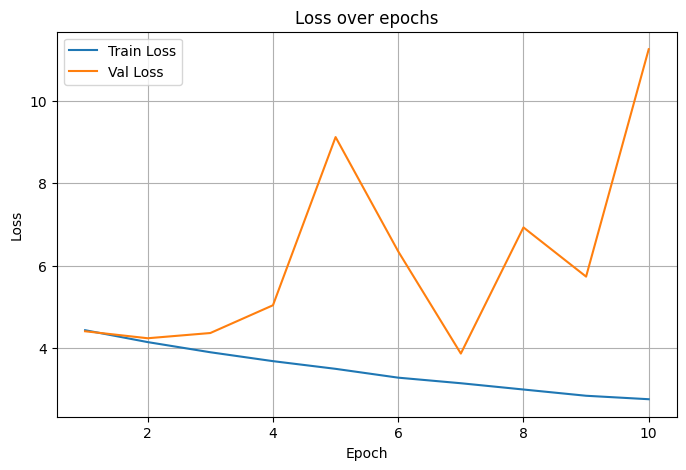

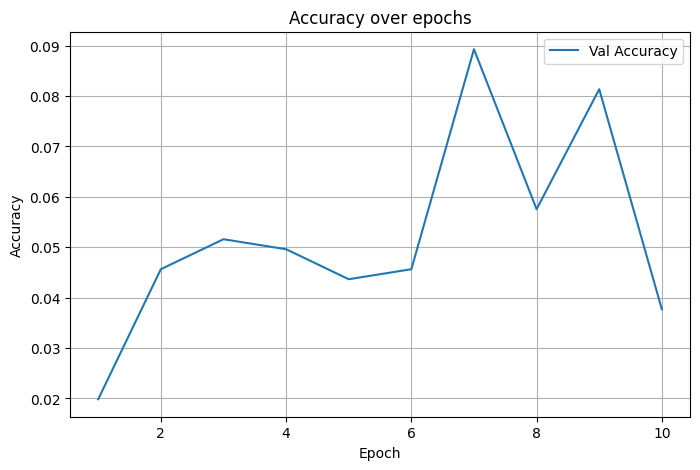

In [44]:
display(custom_model_train_history)

plot_training_history(custom_model_train_history)

<a id='step_3_2'></a>
### 3.2. EfficientNet

In [45]:
efficientnet_model_checkpoint_path = f'{OUTPUT_PATH}/models/efficientnet_model'
os.makedirs(efficientnet_model_checkpoint_path, exist_ok=True)

efficientnet_model_train_history = train_model(
    model=efficientnet_model,
    model_path=efficientnet_model_checkpoint_path,
    train_loader=train_loader,
    val_loader=val_loader,
    classes_names=classes_names,
    num_epochs=num_epochs,
    device=device,
    verbose=verbose
)

 10%|█         | 1/10 [01:42<15:22, 102.56s/it]

epoch 1/10 | train_loss=2.9077 | val_loss=5.0684 | val_accuracy=0.0139 | 


 20%|██        | 2/10 [03:28<13:54, 104.26s/it]

epoch 2/10 | train_loss=0.6930 | val_loss=5.7381 | val_accuracy=0.0079 | 


 30%|███       | 3/10 [05:10<12:03, 103.41s/it]

...

epoch 8/10 | train_loss=0.1210 | val_loss=0.4714 | val_accuracy=0.8571 | 


 90%|█████████ | 9/10 [15:28<01:43, 103.22s/it]

epoch 9/10 | train_loss=0.0893 | val_loss=0.4135 | val_accuracy=0.8750 | 


100%|██████████| 10/10 [17:11<00:00, 103.11s/it]

epoch 10/10 | train_loss=0.1036 | val_loss=0.4239 | val_accuracy=0.8651 | 


,epoch,train_loss,val_loss,val_accuracy
0,1,2.907715,5.068355,0.013889
1,2,0.692962,5.738098,0.007937
2,3,0.364504,2.729343,0.287698
3,4,0.236631,0.567832,0.839286
4,5,0.184172,0.458438,0.857143
5,6,0.157910,0.442749,0.876984
6,7,0.127830,0.410687,0.882937
7,8,0.120987,0.471445,0.857143
8,9,0.089311,0.413460,0.875000
9,10,0.103593,0.423945,0.865079


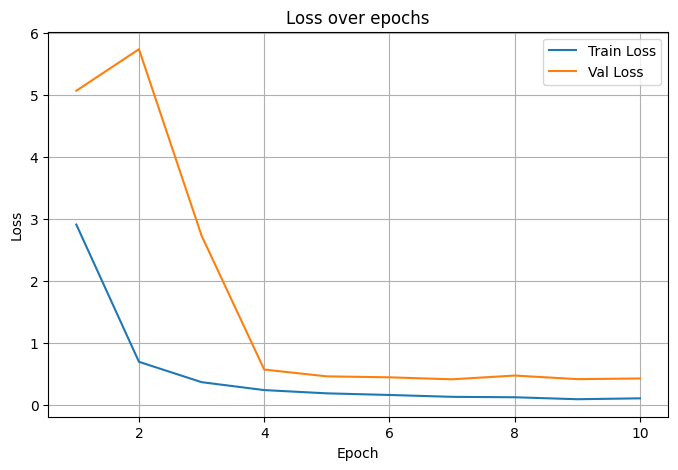

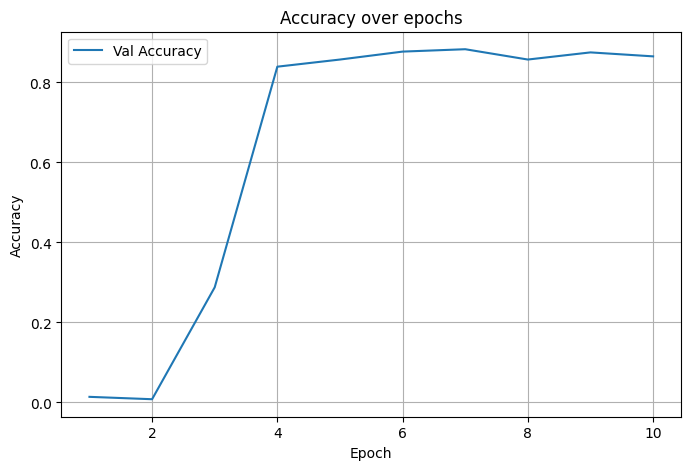

In [46]:
display(efficientnet_model_train_history)

plot_training_history(efficientnet_model_train_history)

<a id='step_3_3'></a>
### 3.3. MobileNet

In [47]:
mobilenet_model_checkpoint_path = f'{OUTPUT_PATH}/models/mobilenet_model'
os.makedirs(mobilenet_model_checkpoint_path, exist_ok=True)

mobilenet_model_train_history = train_model(
    model=mobilenet_model,
    model_path=mobilenet_model_checkpoint_path,
    train_loader=train_loader,
    val_loader=val_loader,
    classes_names=classes_names,
    num_epochs=num_epochs,
    device=device,
    verbose=verbose
)

 10%|█         | 1/10 [01:41<15:16, 101.78s/it]

epoch 1/10 | train_loss=3.7122 | val_loss=4.7586 | val_accuracy=0.0298 | 


 20%|██        | 2/10 [03:24<13:36, 102.12s/it]

epoch 2/10 | train_loss=1.7303 | val_loss=6.4588 | val_accuracy=0.0258 | 


 30%|███       | 3/10 [05:04<11:50, 101.53s/it]

...

epoch 8/10 | train_loss=0.2337 | val_loss=26.6990 | val_accuracy=0.0079 | 


 90%|█████████ | 9/10 [15:08<01:40, 100.55s/it]

epoch 9/10 | train_loss=0.1922 | val_loss=23.9871 | val_accuracy=0.0119 | 


100%|██████████| 10/10 [16:48<00:00, 100.85s/it]

epoch 10/10 | train_loss=0.1628 | val_loss=24.4694 | val_accuracy=0.0238 | 


,epoch,train_loss,val_loss,val_accuracy
0,1,3.712247,4.758569,0.029762
1,2,1.730285,6.458830,0.025794
2,3,1.005461,6.637614,0.021825
3,4,0.656293,6.561772,0.011905
4,5,0.472120,21.918301,0.013889
5,6,0.355746,41.334691,0.019841
6,7,0.272102,36.551079,0.015873
7,8,0.233723,26.698967,0.007937
8,9,0.192207,23.987103,0.011905
9,10,0.162804,24.469377,0.023810


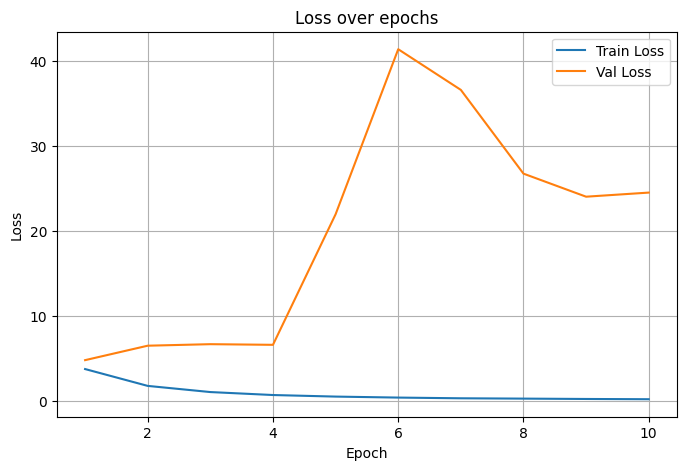

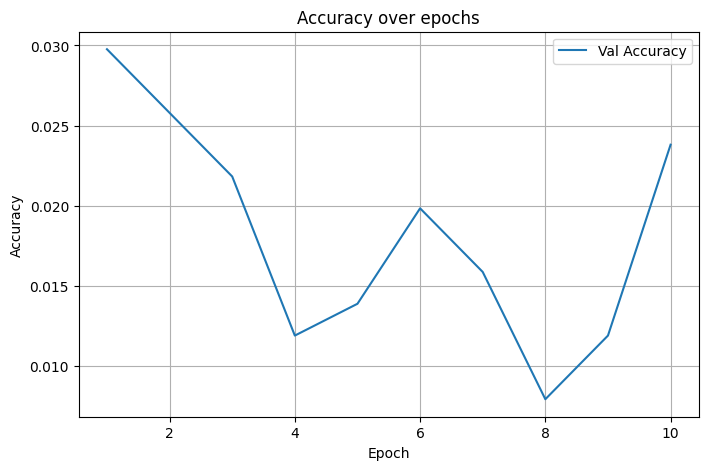

In [48]:
display(mobilenet_model_train_history)

plot_training_history(mobilenet_model_train_history)

**Выводы по этапу**

1. Ошибки на обучающем и валидационном датасетах распечатаны в конце каждой эпохи для всех моделей.
2. Для каждой модели сохранены лучшие конфигурации на валидации
3. Из 3-х моделей за 10 эпох действительно обучилась только 1 модель - EfficientNet

<a id='step_4'></a>
## 4. Оценка качества

1. Рассчитайте метрики обученного классификатора, используя проверочный датасет. 
2. Выведите метрики для каждого класса (Precision, Recall, F1) и accuracy для каждого класса. 
3. Оцените полученные метрики, ответив на вопросы:
    1. На каких 5 классах модель ошибается чаще всего?
    2. Почему модель может ошибаться на этих классах?
    3. На каих классах модель не совершает ошибок?
    4. Почему эти классы модель распознаёт безошибочно?
    5. Как можно улучшить точность классификатора?
    6. Как ещё можно проанализировать результаты и ошибки модели?

Оценку качества проведем на всех моделях (в лучших конфигурациях). Однако выводы будем делать только для EfficientNet.

Рассчитаем метрики обученных классификаторов.
* Метрики Precision, Recall, F1 для каждого класса получим с помощью classification_report. Общий Accuracy тож еполучим оттуда.
* Accuracy для каждого класса фактически совпадает с recall, т.к. рассчитывается как доля правильно классифицированных объектов среди всех объектов данного класса. Поэтому отдельно считать не будем, а просто скопируем соответсвующую колонку.
* Выведем топ-5 классов, на которых модель ошибается чаще всего. Отбирать их будем по наименьшему F1
* Выведем 5 случайных классов, на которых модель не совершает ошибок
* Ошибки дополнительно посмотрим на матрице ошибок (confusion_matrix)

In [49]:
def analyze_model_quality(model, loader, device, classes_names):
    accuracy, report, cm = evaluate_quality(model, loader, device, classes_names)
    
    metrics_df = pd.DataFrame(report).T
    metrics_df['accuracy'] = metrics_df['recall']

    cm_df = pd.DataFrame(cm, index=classes_names, columns=classes_names)
    
    print(f'Accuracy: {accuracy:.4f}')
    print('Метрики по случайным классам')
    display(metrics_df.sample(5))
    print('-'*50)

    worst_classes = metrics_df.sort_values('f1-score').head(5)
    print('Топ-5 классов, на которых модель ошибается чаще всего')
    display(worst_classes[['precision', 'recall', 'f1-score', 'accuracy']])
    print('-'*50)

    best_classes = metrics_df.query('accuracy == 1').copy()
    print(f'Классы, на которых модель не совершает ошибок: {len(best_classes)}')
    display(best_classes[['precision', 'recall', 'f1-score', 'accuracy']].head())
    print('-'*50)
    
    return metrics_df, cm_df

In [50]:
def analyze_model_errors(cm_df, classes_names):
    errors = cm_df.to_numpy().copy()
    # обнуляем главную диагональ, потому что там находятся правильные ответы, а нас интересуют ошибки
    np.fill_diagonal(errors, 0)
    
    # получаем топ-10 самых частых ошибок в предсказаниях
    error_indices = np.unravel_index(np.argsort(errors, axis=None)[::-1][:5], errors.shape)
    
    for i, j in zip(*error_indices):
        print(f'{classes_names[i]} -> {classes_names[j]} : {errors[i,j]}')

<a id='step_4_1'></a>
### 4.1. Собственная модель

In [51]:
best_custom_model = MedsClassifier(num_classes)

best_custom_model_path = f'{custom_model_checkpoint_path}/best_model.pt'
best_custom_model.load_state_dict(torch.load(best_custom_model_path, weights_only=True))

best_custom_model = best_custom_model.to(device)

In [52]:
best_custom_model_metrics_df, best_custom_model_cm_df = analyze_model_quality(best_custom_model, val_loader, device, classes_names)

Accuracy: 0.0893
Метрики по случайным классам


,precision,recall,f1-score,support,accuracy
urzinol,0.000000,0.000000,0.000000,6.0,0.000000
acc_long_600_mg,0.000000,0.000000,0.000000,6.0,0.000000
diclopram_75-mg_20-mg,0.026316,0.166667,0.045455,6.0,0.166667
condrosulf_800_mg,0.000000,0.000000,0.000000,6.0,0.000000
bila_git,0.000000,0.000000,0.000000,6.0,0.000000


--------------------------------------------------
Топ-5 классов, на которых модель ошибается чаще всего


,precision,recall,f1-score,accuracy
acc_long_600_mg,0.0,0.0,0.0,0.0
akineton_2_mg,0.0,0.0,0.0,0.0
calci_kid,0.0,0.0,0.0,0.0
bila_git,0.0,0.0,0.0,0.0
betaloc_50_mg,0.0,0.0,0.0,0.0


--------------------------------------------------
Классы, на которых модель не совершает ошибок: 0


,precision,recall,f1-score,accuracy


--------------------------------------------------


In [53]:
analyze_model_errors(best_custom_model_cm_df, classes_names)

sedatif_pc -> cetirizin_10_mg : 5
neo_ferro_folgamma_114_mg_0_8_mg -> diclopram_75-mg_20-mg : 5
nolpaza_20_mg -> atoris_20_mg : 5
rubophen_500_mg -> algopyrin_500_mg : 5
nurofen_forte_400_mg -> algopyrin_500_mg : 5


<a id='step_4_2'></a>
### 4.2. EfficientNet

In [55]:
best_efficientnet_model = efficientnet_b0()
best_efficientnet_model.classifier = nn.Linear(1280, num_classes)

best_efficientnet_model_path = f'{efficientnet_model_checkpoint_path}/best_model.pt'
best_efficientnet_model.load_state_dict(torch.load(best_efficientnet_model_path, weights_only=True))

best_efficientnet_model = best_efficientnet_model.to(device)

In [56]:
best_efficientnet_model_metrics_df, best_efficientnet_model_cm_df = analyze_model_quality(best_efficientnet_model, val_loader, device, classes_names)

Accuracy: 0.8829
Метрики по случайным классам


,precision,recall,f1-score,support,accuracy
strepsils,1.000000,1.000000,1.000000,6.0,1.000000
nebivolol_sandoz_5_mg,0.714286,0.833333,0.769231,6.0,0.833333
concor_10_mg,1.000000,1.000000,1.000000,6.0,1.000000
sedatif_pc,0.833333,0.833333,0.833333,6.0,0.833333
tritace_hct_5_mg_25_mg,0.750000,1.000000,0.857143,6.0,1.000000


--------------------------------------------------
Топ-5 классов, на которых модель ошибается чаще всего


,precision,recall,f1-score,accuracy
lactiv_plus,0.75,0.5,0.600000,0.5
covercard_plus_10_mg_2_5_mg_5_mg,1.00,0.5,0.666667,0.5
kalcium_magnezium_cink,1.00,0.5,0.666667,0.5
neo_citran,1.00,0.5,0.666667,0.5
naprosyn_250_mg,1.00,0.5,0.666667,0.5


--------------------------------------------------
Классы, на которых модель не совершает ошибок: 46


,precision,recall,f1-score,accuracy
acc_long_600_mg,1.000000,1.0,1.000000,1.0
akineton_2_mg,1.000000,1.0,1.000000,1.0
algoflex_rapid_400_mg,0.857143,1.0,0.923077,1.0
algopyrin_500_mg,0.750000,1.0,0.857143,1.0
ambroxol_egis_30_mg,1.000000,1.0,1.000000,1.0


--------------------------------------------------


In [57]:
analyze_model_errors(best_efficientnet_model_cm_df, classes_names)

neo_citran -> ocutein : 3
olicard_60_mg -> merckformin_xr_1000_mg : 2
aspirin_ultra_500_mg -> algopyrin_500_mg : 2
urzinol -> valeriana_teva : 2
teva_ambrobene_30_mg -> tritace_hct_5_mg_25_mg : 2


За 10 эпох у нас обучилась только данная модель. Проанализируем результаты детальнее.

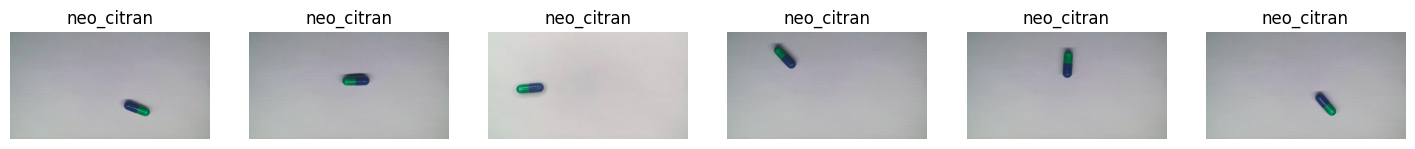

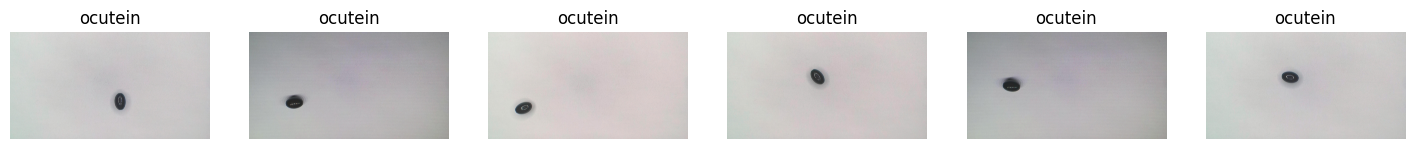

In [62]:
show_images_from_class(raw_val_dataset, class_name='neo_citran', n=6)
show_images_from_class(raw_val_dataset, class_name='ocutein', n=6)

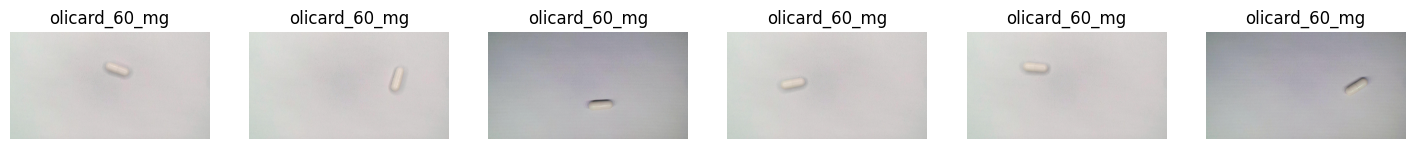

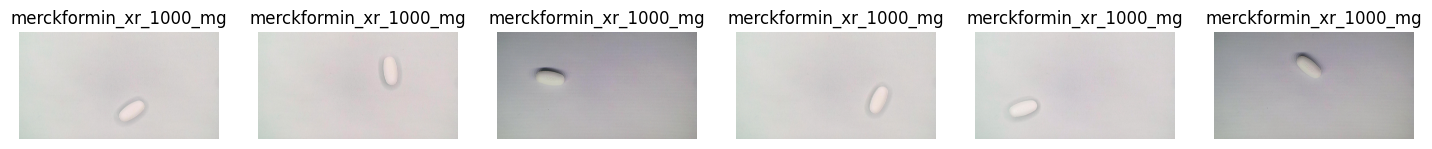

In [64]:
show_images_from_class(raw_val_dataset, class_name='olicard_60_mg', n=6)
show_images_from_class(raw_val_dataset, class_name='merckformin_xr_1000_mg', n=6)

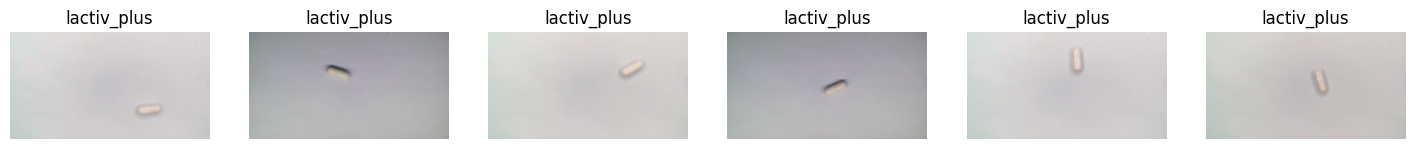

In [69]:
show_images_from_class(raw_val_dataset, class_name='lactiv_plus', n=6)

1. `На каких 5 классах модель ошибается чаще всего?`<br>
Выше выведены топ-5 классов, на которых модель ошибается чаще всего: `lactiv_plus`, `covercard_plus_10_mg_2_5_mg_5_mg`, `kalcium_magnezium_cink`	, `neo_citran`, `naprosyn_250_mg`. Именно эти классы имеют наименьший F1-score.<br>
По recall видно, что классификатор узнал только половину (3 из 6) таблеток из данных классов.
2. `Почему модель может ошибаться на этих классах?`<br>
Классификатор может ошибаться, потому что путает эти таблектки с другими.<br>
Дополнительно была посчитана матрица ошибок. С помощью нее можно посмотреть есть ли тенденция к ошибкам, т.е. классификатор ошибается предсказывает случайный класс или он предсказывает другой класс, потому что таблетки похожи.<br>
Видно, например, что `neo_citran` находится в топ-5 классов, где модель ошибается. По матрице ошибок видно, что в 3-х случаях (как раз все) классификатор предсказывает `ocutein`. Выше вывели изображения из валидационного датасета. Видно, что таблетки визуально очень похожи: продолговатой формы, темного цвета. Действительно, их можно перепутать.<br>
Посмотрим еще случаи ошибки предсказания `olicard_60_mg`. Классификатор в 2-х случаях предсказывает `merckformin_xr_1000_mg`. Опять же, очень схожие таблетки: белые, продолговатые.<br>
Ну и покажем таблкетки `lactiv_plus`. Видно, что на ней можно ошибиться, очень похожа на тот же `olicard_60_mg`. Здесь нет уже "систематической" ошибки, просто несколько раз предсказывается другой класс.

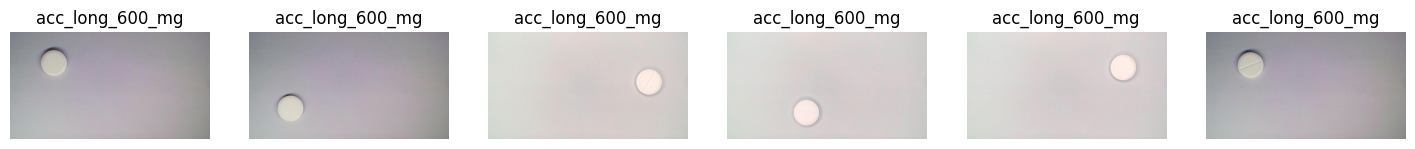

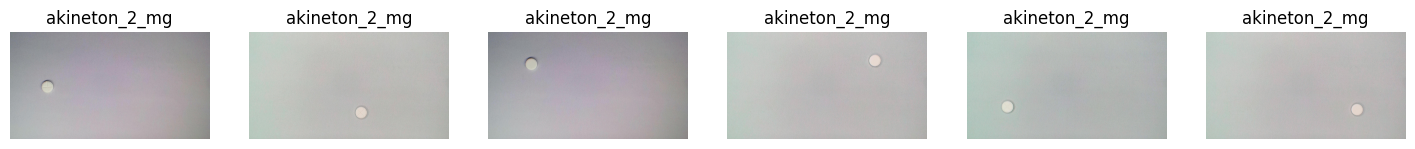

In [68]:
show_images_from_class(raw_val_dataset, class_name='acc_long_600_mg', n=6)
show_images_from_class(raw_val_dataset, class_name='akineton_2_mg', n=6)

3. `На каких классах модель не совершает ошибок?`<br>
На 46 классах модель не совершает ошибок. Выше указаны 5 представителей (для компактности): `acc_long_600_mg`, `akineton_2_mg`, `algoflex_rapid_400_mg`, `algopyrin_500_mg`, `ambroxol_egis_30_mg`.
4. `Почему эти классы модель распознаёт безошибочно?`<br>
Модель предсказывает данные классы безошибочно, потому что эти таблеки имеют отличительные особенности. Они скорее всего имеют уникальное сочетание формы, размера, текстуры и цвета. Это позволяет однозначно определить класс таблеток.<br>
Выше вывели 2 класса: `acc_long_600_mg`, `akineton_2_mg`. Уже по названиям видно, что первая таблетка должна быть очень большой (600 мг), а вторая очень маленькой (2 мг). На изображениях сразу видно разницу между ними.

5. `Как можно улучшить точность классификатора?`<br>
У данной модели Accuarcy = 88% (выше желаемого порога 75%). Но все равно есть куда расти.
    * На графиках лосса видно, на трейне еще можно уменьшить лосс, а значит потенциально можно увеличить и качество на валидации, нужно только больше эпох обучения.
    * Также, если мы все-таки достигли потолка по качеству, значит у нас может быть слабенький классификатор. Нужно добавить еще один слой, чтобы модель лучше работала с выделенными фичами.
    * Можно поработать с аугментацией данных. Сейчас, напомню, изменения контрастности было отключено в угоду скорости. Можно как просто добавить аугментацию в тренировочный датасет (количество изображений не изменится), так и обогатить датасет новыми изображениями (которые есть + несколько аугметированных для каждого изображения).
6. `Как ещё можно проанализировать результаты и ошибки модели?`<br>
Можно детально проанализировать конкретные примеры, когда модель ошиблась. Вывести эти изображения предсказываемого и предсказанного классов и предположить, почему классификатор мог принять такое решение. Например очень схожая форма и цвет, но разные размеры. Значить нужно обогатить выборку именно в эту сторону.

<a id='step_4_3'></a>
### 4.3. MobileNet

In [59]:
best_mobilenet_model = mobilenet_v3_small()
best_mobilenet_model.classifier = nn.Linear(576, num_classes)

best_mobilenet_model_path = f'{mobilenet_model_checkpoint_path}/best_model.pt'
best_mobilenet_model.load_state_dict(torch.load(best_mobilenet_model_path, weights_only=True))

best_mobilenet_model = best_mobilenet_model.to(device)

In [60]:
best_mobilenet_model_metrics_df, best_mobilenet_model_cm_df = analyze_model_quality(best_mobilenet_model, val_loader, device, classes_names)

Accuracy: 0.0298
Метрики по случайным классам


,precision,recall,f1-score,support,accuracy
c_vitamin_teva_500_mg,0.0,0.0,0.0,6.0,0.0
lordestin_5_mg,0.0,0.0,0.0,6.0,0.0
milurit_300_mg,0.0,0.0,0.0,6.0,0.0
covercard_plus_10_mg_2_5_mg_5_mg,0.0,0.0,0.0,6.0,0.0
atoris_20_mg,0.0,0.0,0.0,6.0,0.0


--------------------------------------------------
Топ-5 классов, на которых модель ошибается чаще всего


,precision,recall,f1-score,accuracy
advil_ultra_forte,0.0,0.0,0.0,0.0
akineton_2_mg,0.0,0.0,0.0,0.0
algoflex_forte_dolo_400_mg,0.0,0.0,0.0,0.0
algoflex_rapid_400_mg,0.0,0.0,0.0,0.0
ambroxol_egis_30_mg,0.0,0.0,0.0,0.0


--------------------------------------------------
Классы, на которых модель не совершает ошибок: 1


,precision,recall,f1-score,accuracy
dulsevia_60_mg,0.014151,1.0,0.027907,1.0


--------------------------------------------------


In [61]:
analyze_model_errors(best_mobilenet_model_cm_df, classes_names)

lordestin_5_mg -> dulsevia_60_mg : 6
c_vitamin_teva_500_mg -> dulsevia_60_mg : 6
urotrin -> dulsevia_60_mg : 6
coldrex -> dulsevia_60_mg : 6
cataflam_dolo_25_mg -> dulsevia_60_mg : 6


**Выводы по этапу**

В резульате обучилась только одна модель - EfficientNet. Accuracy 88% (>75%).<br>
Подробные ответы на вопросы даны в соответствующем пункте.

<a id='step_5'></a>
## 5. Выводы

В ходе работы был подготовлен датасет изображений таблеток, выполнена предобработка данных и обучены несколько моделей классификации: собственная сверточная нейронная сеть, а также предобученные модели EfficientNet и MobileNet. Для всех моделей была проведена оценка качества на валидационном датасете с использованием метрик Precision, Recall, F1 и общей Accuracy.

Наилучший результат показала модель EfficientNet, достигнув Accuracy ≈ 88%, что превышает требуемый порог качества (75%). Более высокое качество данной модели объясняется использованием предобученных весов и более эффективной архитектуры, позволяющей лучше извлекать признаки из изображений даже при относительно небольшом объёме обучающего датасета.

Таким образом, наиболее подходящей моделью для данной задачи классификации изображений является EfficientNet, так как она обеспечивает наилучший баланс точности и устойчивости по сравнению с другими рассмотренными моделями.